In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('Bengaluru_House_Data.csv')
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [3]:
cols_to_drop = ['area_type', 'availability', 'society']
existing_cols = [col for col in cols_to_drop if col in df.columns]
df.drop(existing_cols, axis=1, inplace=True)



In [4]:
df.dropna(inplace=True)
df.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [5]:
df.location

0        Electronic City Phase II
1                Chikka Tirupathi
2                     Uttarahalli
3              Lingadheeranahalli
4                        Kothanur
                   ...           
13314           Green Glen Layout
13315                  Whitefield
13317       Raja Rajeshwari Nagar
13318             Padmanabhanagar
13319                Doddathoguru
Name: location, Length: 12710, dtype: str

In [6]:
location_status=df.location.value_counts()

In [7]:
location_status

location
Whitefield                                         514
Sarjapur  Road                                     372
Electronic City                                    300
Kanakpura Road                                     261
Thanisandra                                        231
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1265, dtype: int64

In [8]:
lessthan=location_status[location_status<30]

In [9]:
lessthan

location
Kumaraswami Layout                                 29
Kammasandra                                        29
Basavangudi                                        29
Mahadevpura                                        29
Kudlu                                              29
                                                   ..
Pattegarhpalya                                      1
Tilak Nagar                                         1
12th cross srinivas nagar banshankari 3rd stage     1
Havanur extension                                   1
Abshot Layout                                       1
Name: count, Length: 1170, dtype: int64

In [10]:
df['location']=df['location'].apply(lambda x: "other" if x in lessthan else x)

In [11]:
df.location.value_counts()

location
other              5250
Whitefield          514
Sarjapur  Road      372
Electronic City     300
Kanakpura Road      261
                   ... 
Frazer Town          31
Chikkalasandra       30
Doddathoguru         30
R.T. Nagar           30
Ananth Nagar         30
Name: count, Length: 96, dtype: int64

In [12]:
df.location.value_counts()

location
other              5250
Whitefield          514
Sarjapur  Road      372
Electronic City     300
Kanakpura Road      261
                   ... 
Frazer Town          31
Chikkalasandra       30
Doddathoguru         30
R.T. Nagar           30
Ananth Nagar         30
Name: count, Length: 96, dtype: int64

In [13]:
df

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,other,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,other,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3.0,3.0,112.00
13315,Whitefield,5 Bedroom,3453,4.0,0.0,231.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00
13318,other,4 BHK,4689,4.0,1.0,488.00


In [14]:
df.location.unique()

<StringArray>
['Electronic City Phase II',                    'other',
              'Uttarahalli',                 'Kothanur',
               'Whitefield',             'Marathahalli',
       '7th Phase JP Nagar',                'Gottigere',
                 'Sarjapur',              'Mysore Road',
            'Bisuvanahalli',    'Raja Rajeshwari Nagar',
                  'Kengeri',              'Thanisandra',
                'Bellandur',          'Electronic City',
         'Ramagondanahalli',                'Yelahanka',
                   'Hebbal',           'Kanakpura Road',
 'Electronics City Phase 1',             'Kundalahalli',
           'Chikkalasandra',           'Sarjapur  Road',
             'Doddathoguru',                 'KR Puram',
              'Bhoganhalli',     'Lakshminarayana Pura',
               'Begur Road',                  'Varthur',
             'Bommanahalli',              'Hegde Nagar',
             'Haralur Road',              'Hennur Road',
          'Kalena

In [15]:
df['size'].unique()

<StringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',  '3 Bedroom',      '1 BHK',
       '1 RK',      '4 BHK',  '1 Bedroom',  '2 Bedroom',  '6 Bedroom',
  '8 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',  '9 Bedroom',     '27 BHK',
 '11 Bedroom', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
 '10 Bedroom',     '13 BHK']
Length: 27, dtype: str

In [16]:
df['bedroom']=df['size'].apply(lambda x: int(x.split(' ')[0]))

In [17]:
df

,location,size,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,2
1,other,4 Bedroom,2600,5.0,3.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,3
3,other,3 BHK,1521,3.0,1.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,1.0,51.00,2
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3.0,3.0,112.00,3
13315,Whitefield,5 Bedroom,3453,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00,2
13318,other,4 BHK,4689,4.0,1.0,488.00,4


In [18]:
df=df.drop('size',axis = 1)

In [19]:
df.location = df.location.str.strip()


In [20]:
df.columns


Index(['location', 'total_sqft', 'bath', 'balcony', 'price', 'bedroom'], dtype='str')

In [21]:
df.location

0        Electronic City Phase II
1                           other
2                     Uttarahalli
3                           other
4                        Kothanur
                   ...           
13314           Green Glen Layout
13315                  Whitefield
13317       Raja Rajeshwari Nagar
13318                       other
13319                Doddathoguru
Name: location, Length: 12710, dtype: str

In [22]:
df.total_sqft.unique()

<StringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '1310',        '1800',        '2785',        '1000',
 ...
        '1648',        '1379',        '3124',         '613',         '250',
        '2395',        '2758', '1133 - 1384',         '774',        '4689']
Length: 1976, dtype: str

In [23]:
def clean(sqft):
    r= sqft.split("-")
    if(len(r)==2):
        return (float(r[0])+float(r[1]))/2
    else:
        try:
            return float(sqft)
        except:
            return None

In [24]:
df

,location,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,other,2600,5.0,3.0,120.00,4
2,Uttarahalli,1440,2.0,3.0,62.00,3
3,other,1521,3.0,1.0,95.00,3
4,Kothanur,1200,2.0,1.0,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,1715,3.0,3.0,112.00,3
13315,Whitefield,3453,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,1141,2.0,1.0,60.00,2
13318,other,4689,4.0,1.0,488.00,4


In [25]:
df['total_sqft']=df['total_sqft'].apply(clean)



In [26]:
df.total_sqft.unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ], shape=(1887,))

In [27]:
df.total_sqft.value_counts()

total_sqft
1200.0    788
1100.0    218
1500.0    198
2400.0    177
600.0     172
         ... 
2395.0      1
2758.0      1
1258.5      1
774.0       1
4689.0      1
Name: count, Length: 1886, dtype: int64

In [28]:
df.describe()

,total_sqft,bath,balcony,price,bedroom
count,12668.000000,12710.000000,12710.000000,12710.000000,12710.000000
mean,1511.835167,2.617309,1.584343,106.060778,2.737136
std,1162.097276,1.226000,0.817287,131.766089,1.205097
min,5.000000,1.000000,0.000000,8.000000,1.000000
25%,1100.000000,2.000000,1.000000,49.030000,2.000000
50%,1260.000000,2.000000,2.000000,70.000000,3.000000
75%,1640.000000,3.000000,2.000000,115.000000,3.000000
max,52272.000000,40.000000,3.000000,2912.000000,43.000000


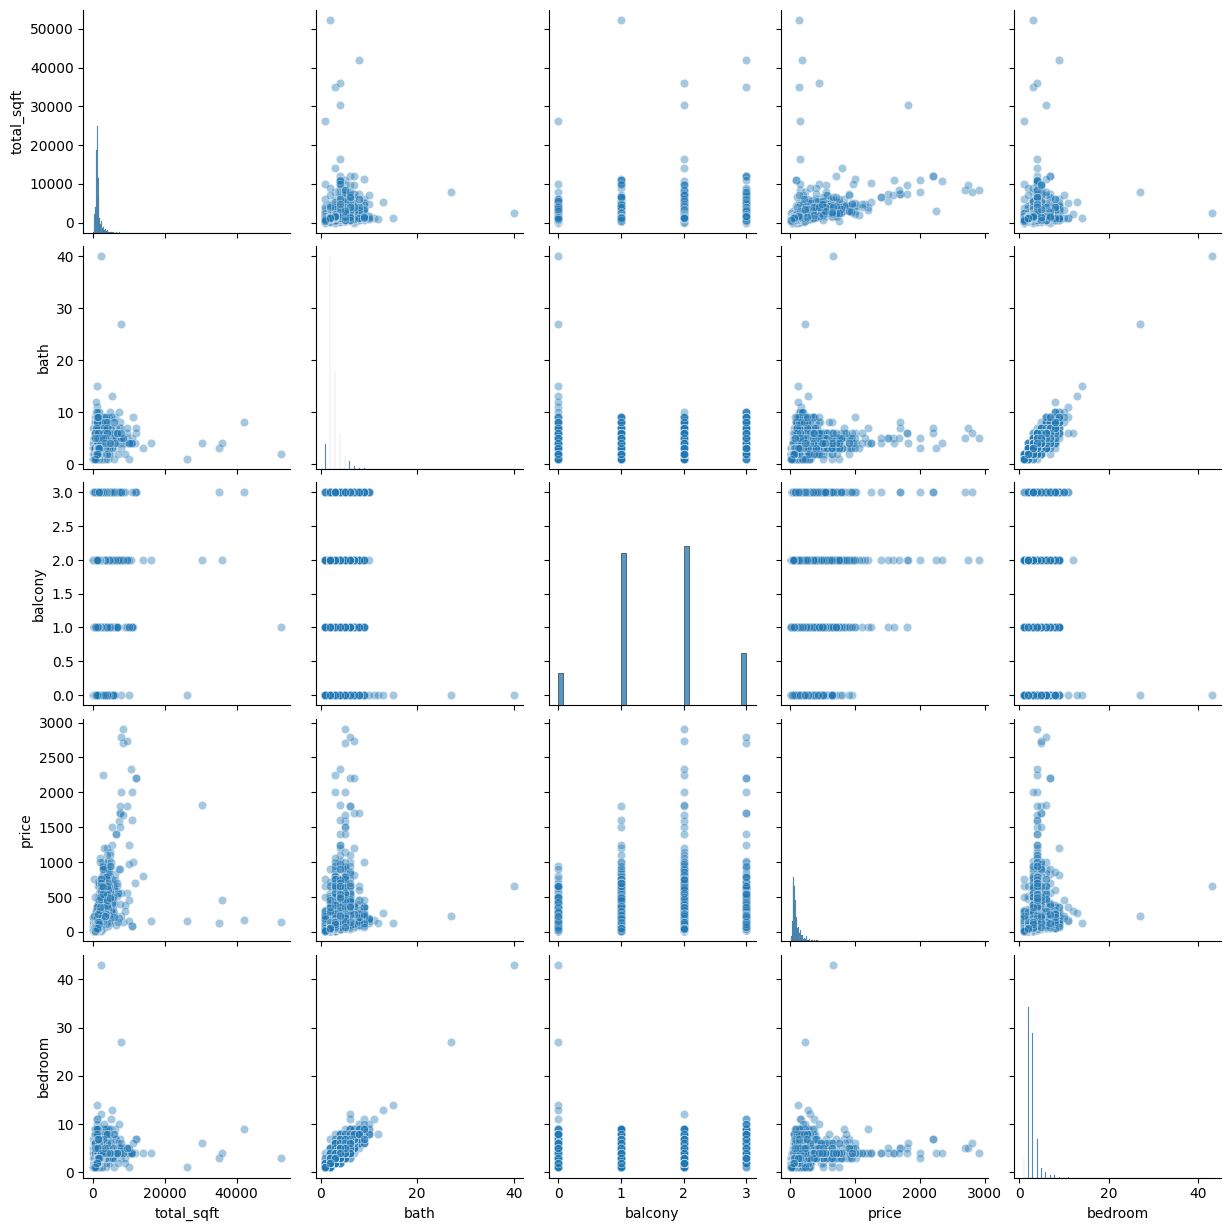

In [29]:
sns.pairplot(data=df,kind='scatter',plot_kws={'alpha':0.4})

In [30]:
df.describe()

,total_sqft,bath,balcony,price,bedroom
count,12668.000000,12710.000000,12710.000000,12710.000000,12710.000000
mean,1511.835167,2.617309,1.584343,106.060778,2.737136
std,1162.097276,1.226000,0.817287,131.766089,1.205097
min,5.000000,1.000000,0.000000,8.000000,1.000000
25%,1100.000000,2.000000,1.000000,49.030000,2.000000
50%,1260.000000,2.000000,2.000000,70.000000,3.000000
75%,1640.000000,3.000000,2.000000,115.000000,3.000000
max,52272.000000,40.000000,3.000000,2912.000000,43.000000


In [31]:
df.total_sqft.isnull().sum()

np.int64(42)

In [32]:
df

,location,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,other,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,other,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3
13315,Whitefield,3453.0,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2
13318,other,4689.0,4.0,1.0,488.00,4


In [33]:

df.dropna()

,location,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,other,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,other,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3
13315,Whitefield,3453.0,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2
13318,other,4689.0,4.0,1.0,488.00,4


In [34]:
df.dropna()

,location,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,other,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,other,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3
13315,Whitefield,3453.0,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2
13318,other,4689.0,4.0,1.0,488.00,4


In [35]:
df['sqft_per_bed']=df['total_sqft']/df['bedroom']

In [36]:
df

,location,total_sqft,bath,balcony,price,bedroom,sqft_per_bed
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.000000
1,other,2600.0,5.0,3.0,120.00,4,650.000000
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.000000
3,other,1521.0,3.0,1.0,95.00,3,507.000000
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3,571.666667
13315,Whitefield,3453.0,4.0,0.0,231.00,5,690.600000
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,570.500000
13318,other,4689.0,4.0,1.0,488.00,4,1172.250000


In [37]:
df.sqft_per_bed.describe()

count    12668.000000
mean       570.060291
std        380.298999
min          0.714286
25%        473.333333
50%        550.000000
75%        622.500000
max      26136.000000
Name: sqft_per_bed, dtype: float64

In [38]:
df2=df[df['sqft_per_bed']>300]

In [39]:
df2


,location,total_sqft,bath,balcony,price,bedroom,sqft_per_bed
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.000000
1,other,2600.0,5.0,3.0,120.00,4,650.000000
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.000000
3,other,1521.0,3.0,1.0,95.00,3,507.000000
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3,571.666667
13315,Whitefield,3453.0,4.0,0.0,231.00,5,690.600000
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,570.500000
13318,other,4689.0,4.0,1.0,488.00,4,1172.250000


In [40]:
df2['price_per_sqft']=round(df2['price']*100000/df2['total_sqft'],2)

In [41]:
df3=df2[df2['price_per_sqft']>2000]
df3


,location,total_sqft,bath,balcony,price,bedroom,sqft_per_bed,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.000000,3699.81
1,other,2600.0,5.0,3.0,120.00,4,650.000000,4615.38
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.000000,4305.56
3,other,1521.0,3.0,1.0,95.00,3,507.000000,6245.89
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.000000,4250.00
...,...,...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3,571.666667,6530.61
13315,Whitefield,3453.0,4.0,0.0,231.00,5,690.600000,6689.83
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,570.500000,5258.55
13318,other,4689.0,4.0,1.0,488.00,4,1172.250000,10407.34


In [42]:
df3.price_per_sqft.describe()

count     11815.000000
mean       6135.402957
std        3892.619967
min        2064.220000
25%        4196.320000
50%        5237.080000
75%        6759.910000
max      176470.590000
Name: price_per_sqft, dtype: float64

In [43]:
df3.drop(['sqft_per_bed','price_per_sqft'],axis = 1, inplace = True)

In [44]:
df3

,location,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,other,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,other,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3
13315,Whitefield,3453.0,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2
13318,other,4689.0,4.0,1.0,488.00,4


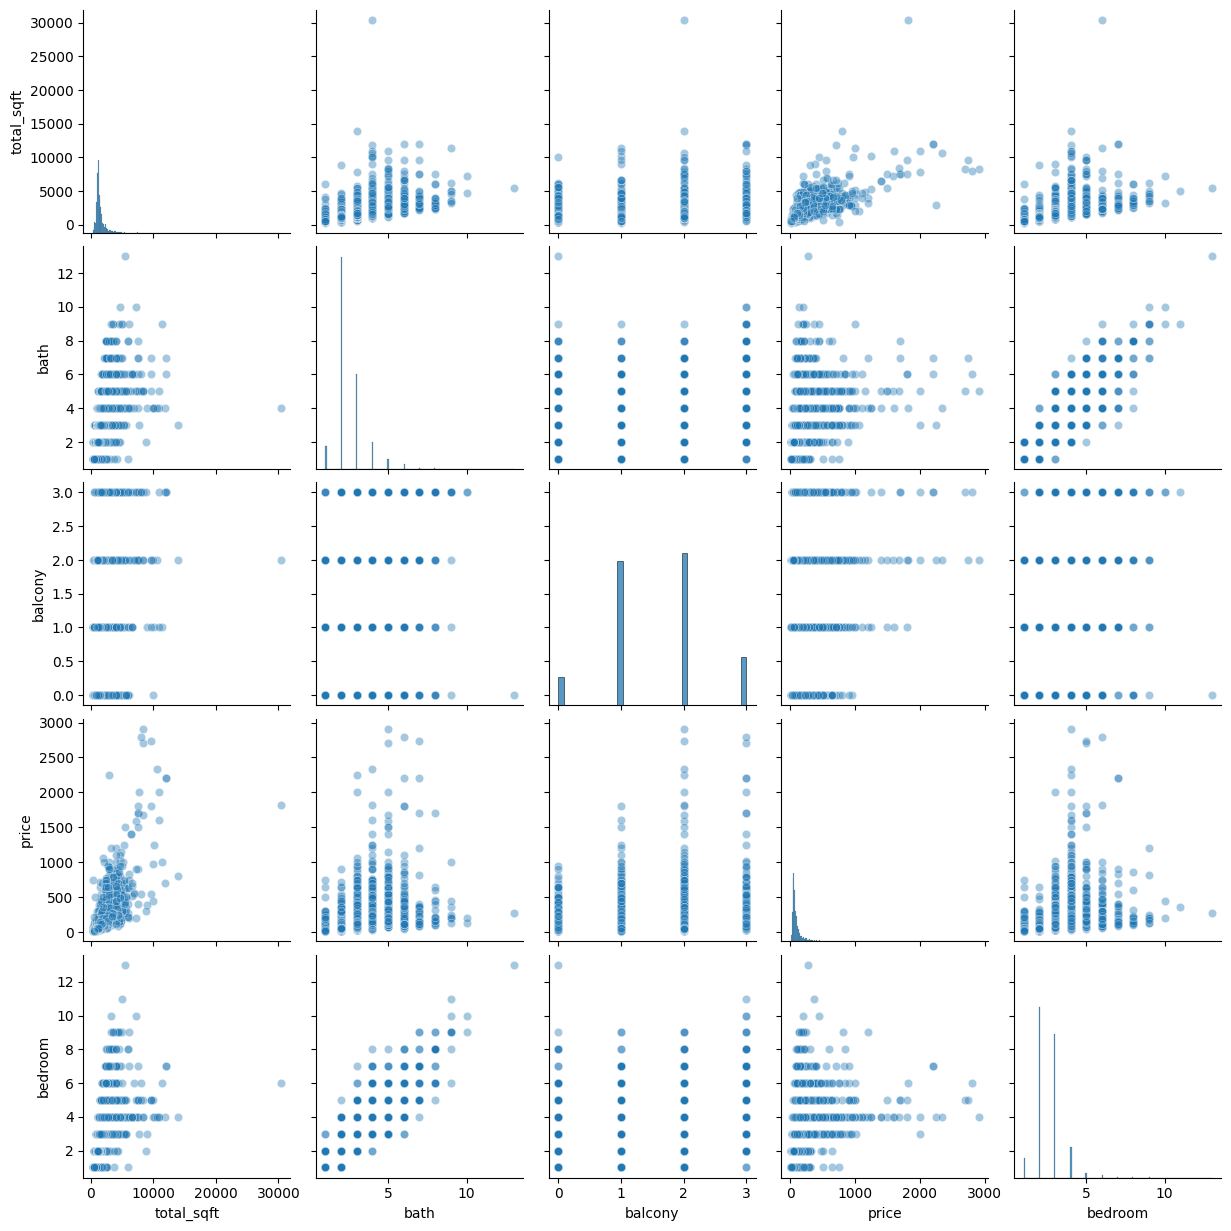

In [45]:
sns.pairplot(data=df3,kind='scatter',plot_kws={'alpha':0.4})

In [46]:
df


,location,total_sqft,bath,balcony,price,bedroom,sqft_per_bed
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,528.000000
1,other,2600.0,5.0,3.0,120.00,4,650.000000
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,480.000000
3,other,1521.0,3.0,1.0,95.00,3,507.000000
4,Kothanur,1200.0,2.0,1.0,51.00,2,600.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3,571.666667
13315,Whitefield,3453.0,4.0,0.0,231.00,5,690.600000
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2,570.500000
13318,other,4689.0,4.0,1.0,488.00,4,1172.250000


In [47]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [48]:
from sklearn.pipeline import make_pipeline

In [49]:
from sklearn.compose import make_column_transformer


In [50]:
col_trans=make_column_transformer((OneHotEncoder(),['location']),remainder='passthrough')


In [51]:
col_trans


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g

In [52]:
ln=LinearRegression()

In [53]:
scaler=StandardScaler()

In [54]:
model=make_pipeline(col_trans,ln)

In [55]:
df3

,location,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,other,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,other,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3
13315,Whitefield,3453.0,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2
13318,other,4689.0,4.0,1.0,488.00,4


In [56]:
df3.drop(columns=['sqft_per_bed'],inplace=True)

KeyError: "['sqft_per_bed'] not found in axis"

In [57]:
df3=df3[df3['bath']<=df3['bedroom']+2]
df3

,location,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,other,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,other,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,112.00,3
13315,Whitefield,3453.0,4.0,0.0,231.00,5
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,60.00,2
13318,other,4689.0,4.0,1.0,488.00,4


In [58]:
X=df3.drop(columns=['price'])

In [59]:
y=df3['price']

In [60]:
X

,location,total_sqft,bath,balcony,bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,2
1,other,2600.0,5.0,3.0,4
2,Uttarahalli,1440.0,2.0,3.0,3
3,other,1521.0,3.0,1.0,3
4,Kothanur,1200.0,2.0,1.0,2
...,...,...,...,...,...
13314,Green Glen Layout,1715.0,3.0,3.0,3
13315,Whitefield,3453.0,4.0,0.0,5
13317,Raja Rajeshwari Nagar,1141.0,2.0,1.0,2
13318,other,4689.0,4.0,1.0,4


In [61]:
y

0         39.07
1        120.00
2         62.00
3         95.00
4         51.00
          ...  
13314    112.00
13315    231.00
13317     60.00
13318    488.00
13319     17.00
Name: price, Length: 11810, dtype: float64

In [62]:
y.info()

<class 'pandas.Series'>
Index: 11810 entries, 0 to 13319
Series name: price
Non-Null Count  Dtype  
--------------  -----  
11810 non-null  float64
dtypes: float64(1)
memory usage: 184.5 KB


In [63]:
y.describe()

count    11810.000000
mean       104.331442
std        133.710533
min         10.000000
25%         48.030000
50%         68.000000
75%        110.000000
max       2912.000000
Name: price, dtype: float64

In [64]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [65]:
X_train,y_train

(                location  total_sqft  bath  balcony  bedroom
 4077           Jalahalli      1570.0   3.0      2.0        3
 2582             Varthur      1055.0   2.0      2.0        2
 2526  7th Phase JP Nagar      2200.0   3.0      2.0        3
 5179        Rachenahalli       680.0   1.0      0.0        1
 8940        Yeshwanthpur      1163.0   2.0      2.0        2
 ...                  ...         ...   ...      ...      ...
 5227        Malleshwaram      2425.0   7.0      3.0        7
 3301               other      1166.0   2.0      1.0        2
 3908               other      1392.0   2.0      1.0        2
 1188           Bellandur      1281.0   2.0      1.0        2
 9162               other      1541.0   2.0      1.0        2
 
 [9448 rows x 5 columns],
 4077    140.00
 2582     45.35
 2526    190.00
 5179     32.64
 8940     64.08
          ...  
 5227    140.00
 3301     53.00
 3908    130.00
 1188     74.00
 9162    181.00
 Name: price, Length: 9448, dtype: float64)

In [66]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [67]:
model.score(X_test,y_test)

0.6703543756203245

In [68]:
df3.head()

,location,total_sqft,bath,balcony,price,bedroom
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,other,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,other,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2


In [69]:
input=pd.DataFrame([['Electronic City Phase II'	,2000	,3.0	,2.0,	3]],columns=['location'	,'total_sqft'	,'bath'	,'balcony','bedroom'])

In [70]:
import math


In [71]:
math.floor(model.predict(input)[0]*100000)

13641069

In [72]:
import pickle as pkl


In [73]:
with open('model.pkl','wb') as f:
    pkl.dump(model,f)

In [74]:
df3.location.value_counts()

location
other              4619
Whitefield          511
Sarjapur  Road      369
Electronic City     289
Kanakpura Road      257
                   ... 
Frazer Town          30
Chikkalasandra       28
R.T. Nagar           28
Ananth Nagar         28
Vidyaranyapura       26
Name: count, Length: 96, dtype: int64

In [76]:
df3.head(30).location

0     Electronic City Phase II
1                        other
2                  Uttarahalli
3                        other
4                     Kothanur
5                   Whitefield
8                 Marathahalli
10                  Whitefield
11                  Whitefield
12          7th Phase JP Nagar
13                   Gottigere
14                    Sarjapur
15                 Mysore Road
16               Bisuvanahalli
17       Raja Rajeshwari Nagar
18                       other
19                       other
20                     Kengeri
21                       other
22                 Thanisandra
23                   Bellandur
24                       other
25                       other
26             Electronic City
27                  Whitefield
28            Ramagondanahalli
29             Electronic City
30                   Yelahanka
31               Bisuvanahalli
32                      Hebbal
Name: location, dtype: str